In [1]:
import ROOT
import warnings

import numpy as np
import matplotlib.pyplot as plt

from scipy import integrate
from lmfit import Parameters, minimize

from scipy.optimize import curve_fit 
from tqdm import tqdm

from scipy.signal import fftconvolve
from scipy.special import gamma

from pyazr import azure2

warnings.filterwarnings('ignore')

# Boltzmann constant in keV/K
k = 8.617e-5

# Doppler effect
dopp = np.sqrt( 2 * 1.007 / 19 * 0.250 * k * ( 80 + 273 ) )

print( 'Doppler effect =', dopp )

Doppler effect = 0.02839149987232094


In [2]:
azr = azure2( "20Ne.azr", nprocs=1 )
azr.extrap_mode( )

Calculating Lo-Matrix, Phases, and Penetrabilities...
Calculating Legendre Polynomials...
Calculating Coulomb Amplitudes...
Calculating External Capture Amplitudes...
Initializing Component Segments...
Initializing Component Segments (0 components)...
Calculating EC Amplitudes for Component Segments...


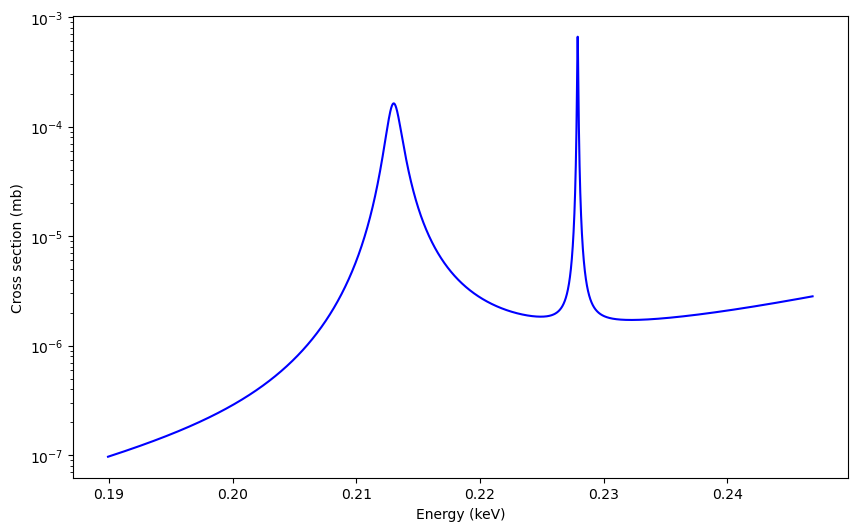

In [14]:
azr_params = [13.057, 1282.52, 13.0719, 2.5e-3, 80]

segments = azr.calculate( azr_params )
energies = azr.calculate_energies( azr_params )

plt.figure( figsize=( 10, 6 ) )

plt.plot( energies[0], segments[0], label='20Ne', color='blue' )
plt.xlabel( 'Energy (keV)' )
plt.ylabel( 'Cross section (mb)' )

plt.yscale( 'log' )

plt.show( )

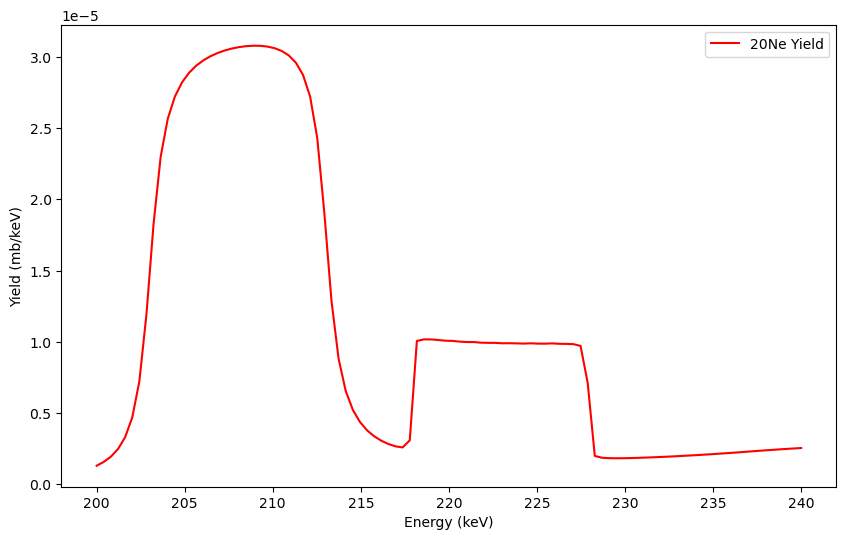

In [15]:
def cross_section( x0 ):
    cross = np.interp( x0, energies[0] * 1e3, segments[0] )
    return cross

# Calculate the yield by integrating the cross section over the energy loss of 10 keV
def yield_integral( energy, de ):
    grid = np.linspace( energy, energy + de, 1000 )
    integral = np.trapz( cross_section( grid ), grid )
    return integral / de

x = np.linspace( 200, 240, 100 )

yields = [ yield_integral( e, 10 ) for e in x ]

plt.figure( figsize=( 10, 6 ) )
plt.plot( x, yields, label='20Ne Yield', color='red' )
plt.xlabel( 'Energy (keV)' )
plt.ylabel( 'Yield (mb/keV)' )
plt.legend()
plt.show()